# Regression Setup, Train-test Split

This notebook is designed for learners who are building practical machine-learning judgment, not just running code. By the end, you should be able to explain and defend each modeling choice.

By the end of this notebook, you should be able to:

- Explain why train-test split is essential for fair model evaluation.
- Explain data leakage and how to avoid it.
- Compare modeling outcomes with and without one-hot encoding.
- Describe how high-dimensional feature spaces can increase overfitting risk.
- Build and evaluate baseline linear regression models using mean squared error (MSE).
- Apply scaling correctly by fitting on training data and transforming both train and test sets.
- Interpret prediction vs. ground-truth plots to diagnose model behavior.

### Concepts Covered

- Supervised learning for regression
- Feature types: numeric vs. categorical
- One-hot encoding and dimensionality growth
- Overfitting and generalization gap
- Train/test protocol and reproducibility
- Preprocessing pipelines (encoding + scaling)
- Model evaluation

### Note
- After each model, compare train performance vs test performance and write one sentence about generalization.
- If results look unexpectedly strong, check for leakage before celebrating.

1. Problem framing: predict `SalePrice` from historical housing features.
2. Honest evaluation: split data into train and test sets that are mutually exclusive.
3. Fit phase: learn model parameters only from training data.
4. Predict phase: generate predictions on unseen test features.
5. Evaluate phase: compare predictions with test labels using error metrics (for example, MSE).
6. Representation choice: encode categorical variables (one-hot) and monitor feature-space growth.
7. Risk control: watch for overfitting, especially in high-dimensional settings.
8. Extension path: repeat evaluation under different split strategies (shuffle split, stratified split where relevant).

### Beginner Checkpoint

Before moving to Task 1, make sure you can answer these questions:

- What is the difference between training error and test error?
- Why is data leakage dangerous?
- Why might one-hot encoding improve modeling but also increase overfitting risk?

### Reflection Template (Use Throughout the Lab)

After each major section, write 2-3 lines:

- Observation: What changed in the data/model output?
- Interpretation: Why do you think that happened?
- Decision: What will you try next, and why?

## Introduction to the Problem

We will be working with a data set based on [housing prices in Ames, Iowa](https://www.kaggle.com/c/house-prices-advanced-regression-techniques). It was compiled for educational use to be a modernized and expanded alternative to the well-known Boston Housing dataset. This version of the data set has had some missing values filled for convenience.

There are an extensive number of features, some of which are described below.

### Predictor

* SalePrice: The property's sale price in dollars. 

### Features

* MoSold: Month Sold
* YrSold: Year Sold   
* SaleType: Type of sale
* SaleCondition: Condition of sale
* MSSubClass: The building class
* MSZoning: The general zoning classification

## Import the necessary libraries


In [ ]:
!pip install pandas numpy matplotlib scikit-learn seaborn | tail -n 1

In [2]:
# Surpress warnings:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

## Task 1: Load and Audit the Dataset

### Objective
Build confidence with the dataset before modeling.

### Instructions

- Load the Ames housing data into a pandas DataFrame.
- Confirm dataset shape (rows, columns).
- Identify the target column (`SalePrice`).
- Count data types (`int64`, `float64`, `object`) to understand preprocessing needs.

### Why this matters

A reliable train-test workflow starts with a clean feature audit. If you skip this step, it is easy to encode or scale incorrectly later.

### Try This (2-minute Challenge)

Before running the next cell, make a quick prediction:

- About how many categorical (`object`) columns do you expect?
- Do you expect more numeric or categorical columns overall?

Then run the cells and compare your prediction to reality.

In [3]:
import pandas as pd
import numpy as np

# Import the data using the file path
data = pd.read_csv("data/Ames_Housing_Sales.csv")
print(data.shape)

(1379, 80)


In [21]:
data.head()

,1stFlrSF,2ndFlrSF,3SsnPorch,BedroomAbvGr,BsmtFinSF1,BsmtFinSF2,BsmtFullBath,BsmtHalfBath,BsmtUnfSF,EnclosedPorch,...,OverallQual,PoolArea,ScreenPorch,TotRmsAbvGrd,TotalBsmtSF,WoodDeckSF,YearBuilt,YearRemodAdd,YrSold,SalePrice
0,856.0,854.0,0.0,3,706.0,0.0,1,0,150.0,0.0,...,7,0.0,0.0,8,856.0,0.0,2003,2003,2008,208500.0
1,1262.0,0.0,0.0,3,978.0,0.0,0,1,284.0,0.0,...,6,0.0,0.0,6,1262.0,298.0,1976,1976,2007,181500.0
2,920.0,866.0,0.0,3,486.0,0.0,1,0,434.0,0.0,...,7,0.0,0.0,6,920.0,0.0,2001,2002,2008,223500.0
3,961.0,756.0,0.0,3,216.0,0.0,1,0,540.0,272.0,...,7,0.0,0.0,7,756.0,0.0,1915,1970,2006,140000.0
4,1145.0,1053.0,0.0,4,655.0,0.0,1,0,490.0,0.0,...,8,0.0,0.0,9,1145.0,192.0,2000,2000,2008,250000.0


In [22]:
data.dtypes.value_counts()

float64    21
int64      16
Name: count, dtype: int64

## Task 2: Estimate the Cost of One-Hot Encoding

Data encoding is the process of converting non-numeric variables (such as text categories) into numeric representations that machine learning models can use. This is necessary because most regression algorithms in scikit-learn operate on numeric matrices and cannot directly learn from raw text labels. In this task, we use one-hot encoding, which represents each category as a binary indicator column (0 or 1).

Before applying one-hot encoding, estimate how many input columns the model will have after categorical values are converted to numbers. This full set of input columns is called the feature space. Estimating feature-space growth early helps you anticipate model complexity, training time, and overfitting risk.

### What is one-hot encoding?

One-hot encoding is a way to convert a categorical text column into multiple binary columns (0 or 1). Each new column represents one category, and a row gets value 1 only for the category it belongs to. If we keep text labels as-is, the model cannot compute numeric relationships from them. One-hot encoding solves this by turning category membership into numeric signals without imposing a fake ranking.

Example: if the column Street has categories Pave and Grvl, one-hot encoding creates binary indicator columns for these categories.

In contrast, assigning numbers like Grvl = 0 and Pave = 1 can incorrectly suggest order or distance between categories. That is acceptable for true ordinal data, but misleading for nominal categories.

In datasets with many columns, encoding is a critical design decision because it can greatly increase dimensionality. Higher dimensionality can improve representation but may also increase variance and overfitting risk.

For this task, let's focus on object-type columns and estimate how many new columns one-hot encoding would create.

### The goal

Calculate how many total encoded features would be added if all object-type columns were one-hot encoded.

Use this rule for each categorical column with n unique categories:

- Number of one-hot columns added = n - 1

We use n - 1 in linear regression to avoid perfect multicollinearity (the dummy variable trap).

Then sum this value across all object columns and compare it with the current number of features.

### Why this matters

If the encoded feature count grows too much, the model can become harder to interpret, slower to train, and more likely to overfit.

### Examples

- If SaleCondition has 6 categories, one-hot encoding contributes 6 - 1 = 5 columns.
- If Street has 2 categories, one-hot encoding contributes 2 - 1 = 1 column.
- If a column has only 1 unique value, it contributes 0 useful one-hot columns and can be ignored.

### Reflection Prompt

After you compute the estimated number of additional columns, answer:

- Is the increase small, moderate, or large relative to the original feature count?
- How might this change affect model variance and interpretability?
- What extra validation step would you add before trusting the encoded model?

In [6]:
# Select the object (string) columns
mask = data.dtypes == object
categorical_cols = data.columns[mask]
print(f"Number of categorical columns: {len(categorical_cols)}")
print(categorical_cols)

Number of categorical columns: 43
Index(['Alley', 'BldgType', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
       'BsmtFinType2', 'BsmtQual', 'CentralAir', 'Condition1', 'Condition2',
       'Electrical', 'ExterCond', 'ExterQual', 'Exterior1st', 'Exterior2nd',
       'Fence', 'FireplaceQu', 'Foundation', 'Functional', 'GarageCond',
       'GarageFinish', 'GarageQual', 'GarageType', 'Heating', 'HeatingQC',
       'HouseStyle', 'KitchenQual', 'LandContour', 'LandSlope', 'LotConfig',
       'LotShape', 'MSZoning', 'MasVnrType', 'MiscFeature', 'Neighborhood',
       'PavedDrive', 'PoolQC', 'RoofMatl', 'RoofStyle', 'SaleCondition',
       'SaleType', 'Street', 'Utilities'],
      dtype='object')


In [7]:
data[categorical_cols]

,Alley,BldgType,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,BsmtQual,CentralAir,Condition1,Condition2,...,MiscFeature,Neighborhood,PavedDrive,PoolQC,RoofMatl,RoofStyle,SaleCondition,SaleType,Street,Utilities
0,NaN,1Fam,TA,No,GLQ,Unf,Gd,Y,Norm,Norm,...,NaN,CollgCr,Y,NaN,CompShg,Gable,Normal,WD,Pave,AllPub
1,NaN,1Fam,TA,Gd,ALQ,Unf,Gd,Y,Feedr,Norm,...,NaN,Veenker,Y,NaN,CompShg,Gable,Normal,WD,Pave,AllPub
2,NaN,1Fam,TA,Mn,GLQ,Unf,Gd,Y,Norm,Norm,...,NaN,CollgCr,Y,NaN,CompShg,Gable,Normal,WD,Pave,AllPub
3,NaN,1Fam,Gd,No,ALQ,Unf,TA,Y,Norm,Norm,...,NaN,Crawfor,Y,NaN,CompShg,Gable,Abnorml,WD,Pave,AllPub
4,NaN,1Fam,TA,Av,GLQ,Unf,Gd,Y,Norm,Norm,...,NaN,NoRidge,Y,NaN,CompShg,Gable,Normal,WD,Pave,AllPub
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1374,NaN,1Fam,NaN,NaN,NaN,NaN,NaN,Y,Norm,Norm,...,NaN,Gilbert,Y,NaN,CompShg,Gable,Normal,WD,Pave,AllPub
1375,NaN,1Fam,TA,No,ALQ,Rec,Gd,Y,Norm,Norm,...,NaN,NWAmes,Y,NaN,CompShg,Gable,Normal,WD,Pave,AllPub
1376,NaN,1Fam,Gd,No,GLQ,Unf,TA,Y,Norm,Norm,...,Shed,Crawfor,Y,NaN,CompShg,Gable,Normal,WD,Pave,AllPub
1377,NaN,1Fam,TA,Mn,GLQ,Rec,TA,Y,Norm,Norm,...,NaN,NAmes,Y,NaN,CompShg,Hip,Normal,WD,Pave,AllPub


In [8]:
# Determine how many extra columns would be created
num_ohc_cols = (data[categorical_cols]
                .apply(lambda x: x.nunique())
                .sort_values(ascending=False))


# No need to encode if there is only one value
small_num_ohc_cols = num_ohc_cols.loc[num_ohc_cols>1]
small_num_ohc_cols

Neighborhood     25
Exterior2nd      16
Exterior1st      14
Condition1        9
SaleType          9
Condition2        8
RoofMatl          8
HouseStyle        8
Functional        7
Heating           6
BsmtFinType2      6
RoofStyle         6
GarageType        6
Foundation        6
SaleCondition     6
LotConfig         5
MSZoning          5
HeatingQC         5
BldgType          5
GarageQual        5
GarageCond        5
FireplaceQu       5
BsmtFinType1      5
Electrical        5
BsmtExposure      4
MiscFeature       4
BsmtQual          4
LotShape          4
LandContour       4
KitchenQual       4
ExterCond         4
ExterQual         4
Fence             4
LandSlope         3
MasVnrType        3
PavedDrive        3
PoolQC            3
BsmtCond          3
GarageFinish      3
Street            2
Alley             2
CentralAir        2
Utilities         2
dtype: int64

In [9]:
# Number of one-hot columns is one less than the number of categories
small_num_ohc_cols -= 1
small_num_ohc_cols

Neighborhood     24
Exterior2nd      15
Exterior1st      13
Condition1        8
SaleType          8
Condition2        7
RoofMatl          7
HouseStyle        7
Functional        6
Heating           5
BsmtFinType2      5
RoofStyle         5
GarageType        5
Foundation        5
SaleCondition     5
LotConfig         4
MSZoning          4
HeatingQC         4
BldgType          4
GarageQual        4
GarageCond        4
FireplaceQu       4
BsmtFinType1      4
Electrical        4
BsmtExposure      3
MiscFeature       3
BsmtQual          3
LotShape          3
LandContour       3
KitchenQual       3
ExterCond         3
ExterQual         3
Fence             3
LandSlope         2
MasVnrType        2
PavedDrive        2
PoolQC            2
BsmtCond          2
GarageFinish      2
Street            1
Alley             1
CentralAir        1
Utilities         1
dtype: int64

In [10]:
# This is quite a few extra columns!
print(small_num_ohc_cols.sum())

204


## Task 3: Build Encoded and Non-Encoded Modeling Datasets

In Task 2, you estimated how much one-hot encoding expands the feature space.
Now you will create two comparable datasets so you can measure the modeling impact of that choice.

### Why we create two datasets

To evaluate preprocessing decisions fairly, we need a controlled comparison:

- Dataset A: one-hot encoded categorical features
- Dataset B: no one-hot encoding (string categorical columns removed)

This lets you isolate the effect of encoding on model performance rather than mixing multiple changes at once.

### Your task

1. Create a full copy of the original dataframe using `.copy()` for the encoded workflow.
2. On the copied dataframe, one-hot encode the selected categorical columns and drop each original text column after encoding it.
3. On the non-encoded dataframe, drop string categorical columns so the model receives numeric inputs only.
4. Keep the target column (`SalePrice`) in both datasets for later train/test comparison.

### Practical note on encoders

For this notebook, `LabelEncoder` followed by `OneHotEncoder` is a simple implementation path.
- `LabelEncoder`: converts each category label into an integer code, such as `Pave -> 1` and `Grvl -> 0`. This is used here as an intermediate step before one-hot encoding.
- `OneHotEncoder`: takes those category values and expands them into binary indicator columns so the model does not treat categories as ordered numbers.

In production pipelines, alternatives such as `OneHotEncoder` inside a `ColumnTransformer` are often preferred for cleaner workflow management.
- `ColumnTransformer`: applies different preprocessing steps to different columns in one organized pipeline. For example, it can one-hot encode categorical columns while leaving numeric columns unchanged or scaling them separately.

In [11]:
# Import the encoders used to transform categorical text into model-ready numeric features
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

# Create a separate copy so the encoded version does not change the original dataframe
data_ohc = data.copy()

# Initialize the encoder that maps text labels to integer codes
le = LabelEncoder()
# Initialize the encoder that expands category codes into binary indicator columns
ohc = OneHotEncoder()

# Loop through each categorical column identified earlier
for col in num_ohc_cols.index:
    
    # Convert the text categories in the current column into integer labels
    dat = le.fit_transform(data_ohc[col]).astype(int)
    
    # Drop the original text column because it will be replaced by encoded columns
    data_ohc = data_ohc.drop(col, axis=1)

    # Apply one-hot encoding to create binary columns for the current category values
    new_dat = ohc.fit_transform(dat.reshape(-1,1))

    # Count how many encoded columns were created for this feature
    n_cols = new_dat.shape[1]
    # Build readable column names such as Neighborhood_0, Neighborhood_1, and so on
    col_names = ['_'.join([col, str(x)]) for x in range(n_cols)]

    # Convert the encoded array into a dataframe aligned with the original row indices
    new_df = pd.DataFrame(new_dat.toarray(), 
                          index=data_ohc.index, 
                          columns=col_names)

    # Join the newly created one-hot encoded columns back to the copied dataframe
    data_ohc = pd.concat([data_ohc, new_df], axis=1)

print(data_ohc.shape)

(1379, 295)


In [12]:
# Column difference is as calculated above
data_ohc.shape[1] - data.shape[1]

215

In [13]:
print(data.shape[1])

# Remove the string columns from the dataframe
data = data.drop(num_ohc_cols.index, axis=1)

print(data.shape[1])

80
37


## Task 4: Train/Test Evaluation of Encoded vs Non-Encoded Data

Now that both datasets are ready, compare how they perform under the same modeling conditions.
The goal is to isolate the effect of feature encoding on generalization performance.

### Why identical splitting matters

To compare fairly, both datasets must be split with the same `random_state` and test size.
This keeps the train/test partitions aligned so performance differences come from preprocessing, not random sampling differences.

### Your task

1. Create train and test splits for both datasets using the same `random_state`.
2. Fit a baseline `LinearRegression` model on each training split.
3. Compute mean squared error (MSE) on both training and test sets for each model.
4. Compare train-vs-test gaps and identify which preprocessing setup generalizes better.

### Key term

- Mean Squared Error (MSE): the average of squared prediction errors; lower values indicate better predictive accuracy.

### What to look for in results

- A low training error with much higher test error suggests overfitting.
- Similar train and test errors suggest better generalization.
- If one-hot encoding greatly increases features, it may reduce training error but worsen test error.

### Example interpretation

- If the one-hot model has lower train MSE but higher test MSE than the non-encoded model, it is likely overfitting.
- If the non-encoded model has slightly higher train MSE but lower test MSE, it is likely the better generalization choice for this baseline setup.

In [14]:
# Import the utility used to split features/target into train and test sets
from sklearn.model_selection import train_test_split

# Define the name of the target (what we want to predict)
y_col = 'SalePrice'

# Build the feature column list for the non-encoded dataset (all columns except target)
feature_cols = [x for x in data.columns if x != y_col]
# Select feature matrix X from the non-encoded dataset
X_data = data[feature_cols]
# Select target vector y from the non-encoded dataset
y_data = data[y_col]

# Split the non-encoded dataset into train and test sets
# test_size=0.3 means 30% test and 70% train
# random_state=42 fixes the random seed so the same rows go to train/test every run; changing the seed usually changes row assignment (and can change model results) while keeping the 70/30 ratio
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.3, random_state=42)
# Build the feature column list for the one-hot encoded dataset (all columns except target)
feature_cols = [x for x in data_ohc.columns if x != y_col]
# Select feature matrix X from the one-hot encoded dataset
X_data_ohc = data_ohc[feature_cols]
# Select target vector y from the one-hot encoded dataset
y_data_ohc = data_ohc[y_col]

# Split the one-hot encoded dataset with the same split settings for fair comparison
# Using the same random_state=42 keeps row selection consistent between both datasets
X_train_ohc, X_test_ohc, y_train_ohc, y_test_ohc = train_test_split(X_data_ohc, y_data_ohc, test_size=0.3, random_state=42)

In [15]:
# Compare the indices to ensure they are identical
(X_train_ohc.index == X_train.index).all()

np.True_

In [16]:
X_train

,1stFlrSF,2ndFlrSF,3SsnPorch,BedroomAbvGr,BsmtFinSF1,BsmtFinSF2,BsmtFullBath,BsmtHalfBath,BsmtUnfSF,EnclosedPorch,...,OverallCond,OverallQual,PoolArea,ScreenPorch,TotRmsAbvGrd,TotalBsmtSF,WoodDeckSF,YearBuilt,YearRemodAdd,YrSold
461,630.0,0.0,0.0,1,515.0,0.0,1,0,115.0,0.0,...,8,4,0.0,0.0,3,630.0,0.0,1970,2002,2009
976,845.0,0.0,0.0,3,0.0,0.0,0,0,0.0,0.0,...,3,4,0.0,0.0,5,0.0,186.0,1957,1957,2009
1128,728.0,728.0,0.0,3,0.0,0.0,0,0,728.0,0.0,...,5,6,0.0,0.0,8,728.0,100.0,2005,2005,2008
904,561.0,668.0,0.0,2,285.0,0.0,0,0,276.0,0.0,...,6,6,0.0,0.0,5,561.0,150.0,1980,1980,2009
506,1601.0,0.0,0.0,3,1358.0,0.0,1,0,223.0,0.0,...,5,8,0.0,0.0,6,1581.0,180.0,2001,2002,2010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,855.0,601.0,0.0,3,311.0,0.0,0,0,544.0,0.0,...,5,6,0.0,0.0,7,855.0,26.0,1978,1978,2010
1130,815.0,875.0,0.0,3,0.0,0.0,0,0,815.0,330.0,...,6,7,0.0,0.0,7,815.0,0.0,1916,1950,2006
1294,1661.0,0.0,0.0,3,831.0,0.0,1,0,161.0,0.0,...,6,6,0.0,178.0,8,992.0,0.0,1955,1996,2008
860,742.0,742.0,0.0,3,0.0,0.0,0,0,742.0,0.0,...,5,6,0.0,0.0,8,742.0,36.0,2005,2005,2009


## Task 5: Compare Train and Test Error (Encoded vs Non-Encoded)

In the next cell, we train a baseline `LinearRegression` model on both datasets and compare their mean squared error (MSE) on the training and test sets.

### What the code does

- Fits the model on the non-encoded training data and predicts on both the train and test splits.
- Stores the train and test MSE for the non-encoded model.
- Repeats the same process for the one-hot encoded dataset.
- Combines the results into a single table so we can compare generalization directly.

### What to look for

- Lower MSE is better.
- A large gap between train and test MSE suggests overfitting.
- If the one-hot encoded model has much lower train error but much higher test error, the added dimensionality is likely hurting generalization.
- If the two error profiles are similar, the model is generalizing more consistently.

In [17]:
# Import the Linear Regression model class
from sklearn.linear_model import LinearRegression
# Import Mean Squared Error (MSE) for model evaluation
from sklearn.metrics import mean_squared_error

# Create a new Linear Regression model instance
LR = LinearRegression()

# Create a list to store train/test error summaries for each dataset
error_df = list()

# -----------------------------
# 1) Non-encoded dataset
# -----------------------------

# Fit the model on the non-encoded training features and target
LR = LR.fit(X_train, y_train)
# Predict target values for the non-encoded training set
y_train_pred = LR.predict(X_train)
# Predict target values for the non-encoded test set
y_test_pred = LR.predict(X_test)

# Compute train and test MSE for the non-encoded dataset and store as a labeled Series
error_df.append(pd.Series({'train': mean_squared_error(y_train, y_train_pred), 'test' : mean_squared_error(y_test,  y_test_pred)}, name='no enc'))

# -----------------------------
# 2) One-hot encoded dataset
# -----------------------------

# Fit the same model on the one-hot encoded training features and target
LR = LR.fit(X_train_ohc, y_train_ohc)
# Predict target values for the one-hot encoded training set
y_train_ohc_pred = LR.predict(X_train_ohc)
# Predict target values for the one-hot encoded test set
y_test_ohc_pred = LR.predict(X_test_ohc)

# Compute train and test MSE for the one-hot encoded dataset and store as a labeled Series
error_df.append(pd.Series({'train': mean_squared_error(y_train_ohc, y_train_ohc_pred),
                           'test' : mean_squared_error(y_test_ohc,  y_test_ohc_pred)},
                          name='one-hot enc'))

# Combine both Series objects into a single comparison table (columns = dataset type)
error_df = pd.concat(error_df, axis=1)
# Display the final error comparison table
error_df

,no enc,one-hot enc
train,1.131507e+09,3.177267e+08
test,1.372182e+09,8.065328e+09


Note that the error values on the one-hot encoded data are very different for the train and test data. In particular, the errors on the test data are much higher. This is because the one-hot encoded model is overfitting the data. We will learn how to deal with issues like this in the next guide.


## Task 6: Compare Feature Scaling on Both Datasets

In this task, you will test whether **feature scaling** improves model performance for the two dataset versions you created earlier:

- the non-encoded dataset
- the one-hot encoded dataset

### What is feature scaling?

Feature scaling means changing numeric input values so they are on a more comparable scale. For example, one feature might range from 0 to 10, while another ranges from 0 to 10,000. If the scales are very different, some models can be influenced more by the larger-valued features.

A **scaler** is a tool that applies a rule to transform numeric values into a new scale.

### Scaling approaches used here

The next code cell compares three common scaling approaches:

- `StandardScaler`: transforms values so they are centered around 0 and scaled using their standard deviation.
- `MinMaxScaler`: rescales values to a fixed range, usually from 0 to 1.
- `MaxAbsScaler`: rescales values by dividing by the largest absolute value, which keeps values between -1 and 1 when the data contains negative numbers.

### What the next two code cells do

1. First, we suppress a pandas chained-assignment warning so the notebook output stays clean.
2. Select the numeric columns with `float` data type. A `float` column contains decimal-number values such as `12.5` or `2450.75`.
3. Apply each scaler to the training data only.
4. Use the same fitted scaler to transform the test data.
5. Train a `LinearRegression` model for each dataset-and-scaler combination.
6. Compute and compare the test mean squared error (MSE) for each setup.

### Why the scaler is fit only on training data

To **fit** a scaler means to calculate the values it needs from the data, such as the mean, standard deviation, minimum, or maximum. The scaler must be fit only on the training data so the test data remains truly unseen during evaluation.

### Why this matters

By comparing several scaling approaches under the same train/test split, you can see whether scaling improves performance on unseen data and whether the effect is different for encoded and non-encoded data.

### What to look for

- Lower test MSE indicates better predictive performance.
- If scaling reduces test error, it is helping the model perform better on unseen data.
- If one dataset benefits more from scaling than the other, that suggests preprocessing is affecting model behavior.
- Because the scaler is fit only on training data, this comparison avoids leaking information from the test set into the model.

In [18]:
# Mute the setting wtih a copy warnings
pd.options.mode.chained_assignment = None

In [19]:
# Import three scaling classes used to transform numeric features
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler

# Create a dictionary of scaler names mapped to scaler objects for easy looping
scalers = {'standard': StandardScaler(),
           'minmax': MinMaxScaler(),
           'maxabs': MaxAbsScaler()}

# Create a dictionary containing both train/test dataset versions to compare
training_test_sets = {
    'not_encoded': (X_train, y_train, X_test, y_test),
    'one_hot_encoded': (X_train_ohc, y_train_ohc, X_test_ohc, y_test_ohc)}


# Get the list of float columns, and the float data so that we don't scale something we already scaled. We're supposed to scale the original data each time.
mask = X_train.dtypes == float
# We typically apply scalers like StandardScaler or MinMaxScaler only to numerical columns with continuous values—often represented as floats because 
# - Scaling makes sense for continuous numerical data where the magnitude and range matter.
# - Non-numeric columns (like categories or text) cannot be meaningfully scaled this way.
# - Integer columns that represent categories or discrete values usually should be handled differently (e.g., encoding).
# - Applying scaling to only float columns avoids errors and ensures the transformation is appropriate.

# Select the float columns that will be scaled
float_columns = X_train.columns[mask]

# Initialize a Linear Regression model used for every scaling/dataset combination
LR = LinearRegression()

# Initialize a dictionary to store test MSE results for each experiment setting
errors = {}
# Loop over each dataset version (non-encoded and one-hot encoded)
for encoding_label, (_X_train, _y_train, _X_test, _y_test) in training_test_sets.items():
    # Loop over each scaler type (standard, minmax, maxabs)
    for scaler_label, scaler in scalers.items():
        # Copy the training set to avoid modifying the original dataframe
        trainingset = _X_train.copy()
        # Copy the test set to avoid modifying the original dataframe
        testset = _X_test.copy()
        # Fit the scaler on training float columns, then transform those columns
        trainingset[float_columns] = scaler.fit_transform(trainingset[float_columns])
        # Transform test float columns using the scaler fitted on training data
        testset[float_columns] = scaler.transform(testset[float_columns])
        # Fit Linear Regression on the prepared training set
        LR.fit(trainingset, _y_train)
        # Predict target values for the prepared test set
        predictions = LR.predict(testset)
        # Build a readable key describing dataset type and scaler type
        key = encoding_label + ' - ' + scaler_label + 'scaling'
        # Store the test MSE for this specific dataset/scaler combination
        errors[key] = mean_squared_error(_y_test, predictions)

errors = pd.Series(errors)
print(errors.to_string())
print('-' * 80)
for key, error_val in errors.items():
    print(key, error_val)

not_encoded - standardscaling        1.372182e+09
not_encoded - minmaxscaling          1.372182e+09
not_encoded - maxabsscaling          1.372182e+09
one_hot_encoded - standardscaling    8.065328e+09
one_hot_encoded - minmaxscaling      8.065328e+09
one_hot_encoded - maxabsscaling      8.065328e+09
--------------------------------------------------------------------------------
not_encoded - standardscaling 1372182358.934503
not_encoded - minmaxscaling 1372182358.934502
not_encoded - maxabsscaling 1372182358.9345126
one_hot_encoded - standardscaling 8065327607.247268
one_hot_encoded - minmaxscaling 8065327607.247668
one_hot_encoded - maxabsscaling 8065327607.087037


### Interpretation of Task 6 Results

The test MSE values are almost identical across the three scaling options for each dataset:

- Non-encoded data: about `1.372e+09` for Standard, MinMax, and MaxAbs scaling.
- One-hot encoded data: about `8.065e+09` for Standard, MinMax, and MaxAbs scaling.

This means changing the scaler did **not** materially change model performance in this experiment.

### Key takeaway

The major performance difference is between the two dataset versions, not between scaling choices:

- The non-encoded dataset performs much better (lower test MSE).
- The one-hot encoded dataset performs much worse (higher test MSE).

So, for this linear regression setup, scaling method is not the main driver of error; the preprocessing choice (non-encoded vs one-hot encoded features) has a much larger impact.

### Why the printed values appear twice

The first block is scientific notation (for example, `1.372182e+09`).
The second block shows the same values in full decimal form (for example, `1372182358.934503`).
They represent the same results in two different display formats.

## Task 7

Plot predictions vs actual for one of the models.


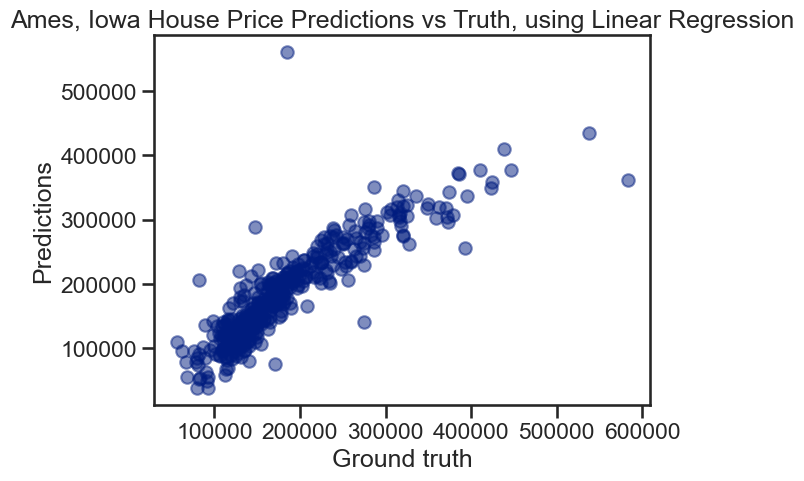

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


sns.set_context('talk')
sns.set_style('ticks')
sns.set_palette('dark')

ax = plt.axes()
# we are going to use y_test, y_test_pred
ax.scatter(y_test, y_test_pred, alpha=.5)

ax.set(xlabel='Ground truth', 
       ylabel='Predictions',
       title='Ames, Iowa House Price Predictions vs Truth, using Linear Regression');

## Conclusion

In this notebook you worked through a complete supervised-regression workflow on the Ames, Iowa housing dataset. Here is a summary of what was accomplished and why each step mattered.

### What You Did

| Step | What happened | Why it matters |
|------|--------------|----------------|
| **Data audit** | Checked shape, dtypes, and target (`SalePrice`) | Prevents silent preprocessing errors downstream |
| **Encoding cost estimation** | Counted unique categories and projected new columns | Anticipates dimensionality growth and overfitting risk |
| **Two-dataset comparison** | Built an encoded (`data_ohc`) and a numeric-only (`X_data`) version | Isolates the effect of categorical encoding on model quality |
| **Train-test split** | Held out a test set before any fitting | Ensures model is evaluated on genuinely unseen data |
| **Data scaling** | Applied `MaxAbsScaler` fit only on training data | Prevents test-set information from leaking into preprocessing |
| **Linear regression** | Trained and evaluated on both encoded and non-encoded feature sets | Provides a fair baseline comparison |
| **Prediction visualization** | Plotted predicted vs actual sale prices | Reveals bias, variance, and systematic misses at a glance |

### Key Takeaways

- **Data leakage is the most common silent mistake.** Fit all scalers and encoders on training data only.
- **One-hot encoding expanded the feature space substantially.** More columns can mean more expressive models, but also higher variance if not regularized.
- **Train error vs test error is your compass.** A large gap signals overfitting; both metrics high signals underfitting.
- **Visual diagnostics complement numeric metrics.** The prediction-vs-truth scatter plot shows patterns that MSE alone cannot.

### Next Steps

- Explore regularization (Ridge, Lasso) to manage the high-dimensional encoded feature space.
- Compare scaling strategies (`StandardScaler`, `MinMaxScaler`) and observe their effect on coefficients.
- Apply cross-validation instead of a single train-test split for more stable performance estimates.
- Revisit feature selection to ask whether all 200+ encoded columns add genuine signal.